# Document Field Extraction using Donut (OCR-Free DocVQA)

Extracts structured fields from document images using **OCR-free visual question answering**.

Unlike LayoutLM (which requires Tesseract OCR to extract text + bounding boxes), **Donut processes raw image pixels directly** — no OCR step, no bounding boxes, no Tesseract installation needed. It uses a vision encoder (Swin Transformer) to understand the image and a text decoder (BART) to generate answers.

## Architecture Flow

GitHub only renders Mermaid diagrams in `.md` files, Issues, Discussions, and PRs — not inside Jupyter notebook markdown cells. See the rendered diagram and full documentation in [README.md](./README.md#architecture).

## Pipeline Summary

| Stage | Component | Description |
|-------|-----------|-------------|
| **1. Input** | `load_image()` | Accepts JPG, PNG, BMP, PDF |
| **2. PDF Detection** | `is_native_pdf()` | Checks if PDF has text layer (>50 chars) |
| **3a. Native PDF** | PyMuPDF | Renders at **150 DPI** |
| **3b. Scanned PDF** | PyMuPDF | Renders at **200 DPI** |
| **3c. Images** | PIL | Converts to RGB (no preprocessing — Donut handles it internally) |
| **4. Processor** | `DonutProcessor` | Resizes + normalises image to 2560×1920 tensor |
| **5. Model** | `naver-clova-ix/donut-base-finetuned-docvqa` | Vision encoder-decoder (~800 MB) |
| **6. Generation** | `model.generate()` | Decodes answer tokens from the prompt |
| **7. Output** | Structured dict | Field values (text answers, no numeric confidence) |

### Key Difference from LayoutLM

| Approach | OCR Required | Image Features | Confidence Score | Accuracy (DocVQA) |
|----------|-------------|----------------|-----------------|-------------------|
| **LayoutLM** (`impira/layoutlm-document-qa`) | ✅ Tesseract | ❌ Text + bbox only | ✅ Numeric (0–1) | ~70% F1 |
| **Donut** (`naver-clova-ix/donut-base-finetuned-docvqa`) | ❌ None | ✅ Raw pixels | ❌ Text answer only | ~84% F1 |

### Model: `naver-clova-ix/donut-base-finetuned-docvqa`

| Feature | Value |
|---|---|
| Architecture | Vision Encoder-Decoder (Swin Transformer + BART decoder) |
| Task | Document Visual Question Answering (DocVQA) |
| Input | PIL Image + task prompt with question |
| Output | Generated answer text |
| Size | ~800 MB |
| License | MIT |

**Prerequisites:**
- `pip install transformers torch pillow sentencepiece` (Donut pipeline — downloads ~800 MB on first run)
- `pip install pymupdf` (for PDF support)
- **No Tesseract required**

## Step 0 — Environment Setup

Adds the notebook's parent folder to Python's import path so project modules
can be imported without installing the package.

### No Tesseract Required

Unlike `impira/layoutlm-document-qa`, **Donut does not use OCR**. You do not need to install
Tesseract or add it to `$PATH`. The model processes raw image pixels directly.

**Required Python packages:**
```bash
pip install transformers torch pillow sentencepiece pymupdf
pip install ipywidgets   # optional — fixes tqdm progress bar display in Jupyter
```

In [12]:
import os
import sys
from pathlib import Path

# Optional: set HF_TOKEN to silence the "unauthenticated requests" warning on
# first model download and get higher rate limits from the HF Hub.
# os.environ.setdefault("HF_TOKEN", "hf_your_token_here")

# Notebook lives in <root>/Hugging face model/naver-clova-ix ---- donut-base-finetuned-docvqa/,
# so we go up two levels to reach the workspace root.
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("No Tesseract needed — Donut is fully OCR-free.")

Project root: /Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing
No Tesseract needed — Donut is fully OCR-free.


## Configuration & Image Discovery

Defines **which images the notebook will process** and **which one to inspect**
in the single-image cells below.

| Variable | Meaning |
|---|---|
| `IMAGE_FOLDER` | Folder scanned for input images |
| `INSPECT_INDEX` | Index into the sorted file list — controls single-image inspection |
| `EXTENSIONS` | File suffixes accepted (case-insensitive) |

In [13]:
# ── Configuration ──────────────────────────────────────────────────────────────
IMAGE_FOLDER = Path.cwd().parent.parent / "test_data" / "sick_notes"
INSPECT_INDEX = 22
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".pdf"}
# ───────────────────────────────────────────────────────────────────────────────

if not IMAGE_FOLDER.exists():
    raise FileNotFoundError(f"Folder not found: {IMAGE_FOLDER}")

image_paths = sorted(
    p for p in IMAGE_FOLDER.rglob("*")
    if p.is_file() and p.suffix.lower() in EXTENSIONS
)

if not image_paths:
    raise FileNotFoundError(f"No images found under {IMAGE_FOLDER}")

# Guard against an out-of-range inspection index (avoids a bare IndexError later).
if INSPECT_INDEX >= len(image_paths):
    raise IndexError(
        f"INSPECT_INDEX={INSPECT_INDEX} but only {len(image_paths)} file(s) found "
        f"(valid range 0–{len(image_paths) - 1}). Lower INSPECT_INDEX."
    )

print(f"Found {len(image_paths)} file(s) under {IMAGE_FOLDER}:")
for i, p in enumerate(image_paths):
    marker = " ← inspect" if i == INSPECT_INDEX else ""
    rel = p.relative_to(IMAGE_FOLDER)
    print(f"  [{i}] {rel}{marker}")

Found 23 file(s) under /Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing/test_data/sick_notes:
  [0] Test data/Sick_Note_1.jpg
  [1] Test data/Sick_note_2.jpg
  [2] Test data/Sick_note_8.pdf
  [3] Test data/sick_note_10.jpg
  [4] Test data/sick_note_12.pdf
  [5] Test data/sick_note_13.jpg
  [6] Test data/sick_note_14.pdf
  [7] Test data/sick_note_15.jpg
  [8] Test data/sick_note_17.pdf
  [9] Test data/sick_note_18.pdf
  [10] Test data/sick_note_19.png
  [11] Test data/sick_note_20.pdf
  [12] Test data/sick_note_21.pdf
  [13] Test data/sick_note_3.jpg
  [14] Test data/sick_note_9.jpg
  [15] authentic/SickNote_AI_jpg1.jpg
  [16] fake/AI_c2pa_image_2.png
  [17] suspicious/Sick_Note_1.jpg
  [18] suspicious/Sick_note_No_Seal.png
  [19] suspicious/date_mismatch.png
  [20] suspicious/negative_no_seal_001.png
  [21] suspicious/sicknote_1.jpg
  [22] suspicious/sicknote_1.png ← inspect


## Step 1 — Helper Functions

Provides image loading and PDF rendering. Unlike the LayoutLM notebook, **no image preprocessing
pipelines are needed** — Donut's `DonutProcessor` handles all resizing and normalisation internally
(it resizes images to 2560×1920 and normalises pixel values).

### PDF Handling

| PDF Type | Detection | DPI | Why |
|----------|-----------|-----|---------|
| **Native PDF** (Word → PDF) | `get_text()` > 50 chars | 150 | Text is vector-based, lower DPI is sufficient |
| **Scanned PDF** (image as PDF) | `get_text()` ≤ 50 chars | 200 | Image needs higher DPI for Donut to read text |

> **Note:** No preprocessing is applied to images. Donut's processor includes its own image
> normalisation (mean/std correction) and resizing — manual preprocessing would interfere with this.

In [14]:
import pymupdf as fitz  # replaces deprecated `import fitz`
from PIL import Image


def is_native_pdf(pdf_path: Path) -> bool:
    """Return True if the PDF has an embedded text layer (native vs scanned)."""
    doc = None
    try:
        doc = fitz.open(str(pdf_path))
        text = doc[0].get_text().strip()
        return len(text) > 50
    except Exception:
        return False
    finally:
        if doc is not None:
            doc.close()


def pdf_page_to_image(pdf_path: Path, page_index: int = 0, dpi: int = 200) -> Image.Image:
    """Render one PDF page to a PIL Image at the given DPI."""
    doc = fitz.open(str(pdf_path))
    try:
        page = doc[page_index]
        mat = fitz.Matrix(dpi / 72, dpi / 72)
        pix = page.get_pixmap(matrix=mat, alpha=False)
        return Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
    finally:
        doc.close()


def load_image(path: Path) -> Image.Image:
    """Load an image or PDF page as a PIL RGB Image.

    No preprocessing is applied — Donut's DonutProcessor handles
    resizing and normalisation internally.
    """
    if path.suffix.lower() == ".pdf":
        native = is_native_pdf(path)
        dpi = 150 if native else 200
        label = "Native PDF" if native else "Scanned PDF"
        print(f"  [{label} — {dpi} DPI]")
        return pdf_page_to_image(path, dpi=dpi)
    img = Image.open(path)
    if img.mode != "RGB":
        img = img.convert("RGB")
    print(f"  [Image — {img.size[0]}×{img.size[1]} px]")
    return img


print("Helper functions loaded.")
print("load_image() — no preprocessing (Donut processor handles it internally)")

Helper functions loaded.
load_image() — no preprocessing (Donut processor handles it internally)


## Step 2 — Donut Model Setup

Loads the `naver-clova-ix/donut-base-finetuned-docvqa` model once and reuses it for all images.

### Model Details

| Property | Value |
|---|---|
| Model ID | `naver-clova-ix/donut-base-finetuned-docvqa` |
| Architecture | `VisionEncoderDecoderModel` (Swin Transformer encoder + BART decoder) |
| Processor | `DonutProcessor` (image normalisation + SentencePiece tokeniser) |
| Task prompt | `<s_docvqa><s_question>{question}</s_question><s_answer>` |
| Output | Generated token sequence, decoded to plain text |
| Size | ~800 MB |

### How Donut Answers Questions

1. The image is encoded into a feature vector by the Swin Transformer.
2. A task prompt `<s_docvqa><s_question>What is the patient name?</s_question><s_answer>` is tokenised.
3. The decoder generates tokens conditioned on both the image features and the prompt.
4. The generated sequence is decoded to text and cleaned to extract just the answer.

### Lazy Singleton Pattern

The model and processor are ~800 MB and take 60–90 seconds to load. They are stored in
module-level variables and returned on subsequent calls without reloading:

```python
_processor, _model = None, None

def _get_donut():
    global _processor, _model
    if _processor is None:  # first call → load
        _processor = DonutProcessor.from_pretrained(_MODEL_ID)
        _model = VisionEncoderDecoderModel.from_pretrained(_MODEL_ID)
    return _processor, _model  # subsequent calls → reuse
```

In [15]:
import re
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel

_MODEL_ID = "naver-clova-ix/donut-base-finetuned-docvqa"

# Task prompt format for the DocVQA fine-tuned checkpoint.
# The model was trained with this exact template — do not modify.
_TASK_PROMPT = "<s_docvqa><s_question>{question}</s_question><s_answer>"

_processor: DonutProcessor | None = None
_model: VisionEncoderDecoderModel | None = None


def _get_donut() -> tuple[DonutProcessor, VisionEncoderDecoderModel]:
    """Return the Donut processor and model, loading them on first call."""
    global _processor, _model
    if _processor is None:
        print(f"Loading Donut model ({_MODEL_ID}) — first call only, ~60–90 sec ...")
        _processor = DonutProcessor.from_pretrained(_MODEL_ID)
        _model = VisionEncoderDecoderModel.from_pretrained(_MODEL_ID)
        _model.eval()
        if torch.cuda.is_available():
            _model = _model.cuda()
            print("Model moved to GPU (CUDA).")
        elif torch.backends.mps.is_available():
            # Apple Silicon GPU — significantly faster than CPU for transformer inference.
            _model = _model.to("mps")
            print("Model moved to GPU (Apple MPS).")
        else:
            print("Running on CPU (no GPU detected).")
        print("Donut model ready.")
    return _processor, _model


# Reset to force reload on next call.
_processor = None
_model = None
print(f"Donut loader defined — model will load on first extract_fields_donut() call.")
print(f"Model ID: {_MODEL_ID}")
print(f"Task prompt template: {_TASK_PROMPT}")

Donut loader defined — model will load on first extract_fields_donut() call.
Model ID: naver-clova-ix/donut-base-finetuned-docvqa
Task prompt template: <s_docvqa><s_question>{question}</s_question><s_answer>


## Step 3 — Field Extraction via Question Answering

The **core extractor**. Asks targeted questions about the document image and
collects the model's text answers into a structured dictionary.

### How Donut Answers Differ from LayoutLM

| Aspect | LayoutLM (`impira`) | Donut (`naver-clova-ix`) |
|--------|---------------------|---------------------------|
| Answer source | Span extracted from OCR text | Token sequence generated by decoder |
| Confidence score | Numeric (0.0–1.0) | None — binary (answered / not answered) |
| Multi-question strategy | Try all variants, keep highest score | Try variants until first non-empty answer |
| Empty answer | Low-score span | Empty string or pad token only |

Because Donut does not return a numeric confidence, we use a **binary confidence**:
- `1.0` — model returned a non-empty answer
- `0.0` — model returned empty string (field not found / not confident)

### Questions per Field

| Field | Primary Question |
|---|---|
| `patient_name` | "What is the patient's full name on this medical certificate?" |
| `doctor_name` | "What is the doctor's name who signed this certificate?" |
| `clinic_name` | "What is the clinic or hospital name on the letterhead?" |
| `certificate_id` | "What is the certificate ID or document number?" |
| `issue_date` | "What is the date this certificate was issued?" |

In [16]:
from typing import Any

# Questions per field — same fields as the LayoutLM notebook for comparability.
#
# Strategy: "first non-empty answer wins" (see extract_fields_donut). Since Donut
# almost always emits *something*, the FIRST question per field is effectively the
# one that decides the result. So each list leads with the most constrained,
# form-label-anchored phrasing — short questions that mirror the exact label text
# on the document ("Patient Name:", "Reg. No:") disambiguate best on DocVQA and
# stop the model from returning the doctor/clinic when asked for the patient.
_FIELD_QUESTIONS: dict[str, list[str]] = {
    "patient_name": [
        "What name is written after 'Patient Name'?",
        "What is the name of the patient being examined?",
        "Who is this medical certificate issued for?",
        "Who is the patient (not the doctor)?",
        "What is the patient's name?",
    ],
    "doctor_name": [
        "What name is written after 'Dr' or 'Doctor'?",
        "Who signed this certificate as the physician?",
        "What is the name of the attending doctor?",
        "Who is the medical practitioner?",
        "What is the doctor's name?",
    ],
    "clinic_name": [
        "What is the hospital or clinic name in the letterhead?",
        "What is the name of the medical facility at the top?",
        "Which healthcare institution issued this?",
        "What is the clinic name?",
    ],
    "certificate_id": [
        "What number is written after 'Ref', 'ID', 'No' or 'Certificate'?",
        "What is the certificate or reference number?",
        "What is the document number?",
        "What is the registration number?",
    ],
    "issue_date": [
        "What date is written after 'Date' or 'Issued on'?",
        "What is the date of issue of this certificate?",
        "On what date was this certificate signed?",
        "What is the issue date?",
    ],
}

# ── Cross-field sanity checks ────────────────────────────────────────────────
_DR_PATTERN    = re.compile(r"^\s*dr\.?\s", re.IGNORECASE)
_CLINIC_TOKENS = {
    "hospital", "clinic", "medical center", "health centre",
    "health center", "infirmary", "surgery", "practice",
}

def _sanity_check(field: str, value: str) -> str | None:
    """Return value if it passes field-specific validation, else None.

    Catches the most common wrong-field leakage:
    - patient_name: rejects values that look like doctor or clinic names.
    - issue_date: rejects values that contain no digit (e.g. place names).
    """
    v = value.lower().strip()
    if field == "patient_name":
        if _DR_PATTERN.match(value):                    # doctor name leaked in
            return None
        if any(t in v for t in _CLINIC_TOKENS):         # clinic name leaked in
            return None
    if field == "issue_date":
        if not re.search(r"\d", v):                     # must contain a digit
            return None
    return value
# ─────────────────────────────────────────────────────────────────────────────


def _ask_donut(encoder_outputs, question: str, processor, model, device) -> str | None:
    """Ask a single question using pre-computed encoder outputs.

    Accepts encoder_outputs (already on device) so the Swin Transformer encoder
    is NOT called again — the image is encoded once per call to extract_fields_donut,
    saving ~4 redundant encoder passes per image (~60-70% faster on CPU).
    """
    try:
        prompt = _TASK_PROMPT.format(question=question)
        decoder_input_ids = processor.tokenizer(
            prompt, add_special_tokens=False, return_tensors="pt"
        ).input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                encoder_outputs=encoder_outputs,
                decoder_input_ids=decoder_input_ids,
                max_length=model.decoder.config.max_position_embeddings,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
                use_cache=True,
                bad_words_ids=[[processor.tokenizer.unk_token_id]],
                return_dict_in_generate=True,
            )

        # Decode the generated sequence. It echoes the whole prompt, e.g.
        #   <s_docvqa><s_question>{question}</s_question><s_answer>{answer}</s>
        # so we must keep ONLY the text after the <s_answer> tag.
        seq = processor.batch_decode(outputs.sequences)[0]
        seq = seq.replace(processor.tokenizer.eos_token, "").replace(
            processor.tokenizer.pad_token, ""
        )

        # Prefer structured parsing (returns {"question": ..., "answer": ...}).
        answer: str | None = None
        try:
            parsed = processor.token2json(seq)
            if isinstance(parsed, dict):
                value = parsed.get("answer")
                if isinstance(value, str):
                    answer = value.strip()
        except Exception:  # noqa: BLE001
            answer = None

        # Fallback: split on <s_answer>, then strip remaining special tokens.
        if not answer:
            if "<s_answer>" in seq:
                seq = seq.split("<s_answer>", 1)[1]
            answer = re.sub(r"<[^>]+>", "", seq).strip()

        return answer if answer else None

    except Exception as e:  # noqa: BLE001
        print(f"  Warning: Donut inference failed for '{question}': {e}")
        return None


def extract_fields_donut(image: Image.Image) -> dict[str, Any]:
    """Extract structured fields from a document image using Donut DocVQA.

    Encodes the image ONCE via the Swin Transformer encoder, then runs the
    BART decoder separately for each question — ~5× faster than re-encoding
    per question. Each answer is validated by _sanity_check before acceptance;
    if it fails the check the next question variant is tried instead.
    """
    processor, model = _get_donut()
    device = next(model.parameters()).device

    # Encode the image once — reused for all 5 fields × their question variants.
    # load_image() already returns RGB so no .convert() needed here.
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        encoder_outputs = model.encoder(pixel_values=pixel_values)

    fields: dict[str, Any] = {}
    for field_name, questions in _FIELD_QUESTIONS.items():
        answer: str | None = None

        for question in questions:
            result = _ask_donut(encoder_outputs, question, processor, model, device)
            if result:
                sane = _sanity_check(field_name, result)
                if sane:
                    answer = sane
                    break  # First non-empty, sane answer wins.

        fields[field_name] = answer
        fields[f"{field_name}_confidence"] = 1.0 if answer else 0.0

    return fields


print("Field extraction function loaded.")
print(f"Fields to extract: {list(_FIELD_QUESTIONS.keys())}")
print("Optimisations: encoder cached per image, cross-field sanity checks active.")
print("Confidence: binary (1.0 = answered, 0.0 = not found) — Donut does not return numeric scores.")

Field extraction function loaded.
Fields to extract: ['patient_name', 'doctor_name', 'clinic_name', 'certificate_id', 'issue_date']
Optimisations: encoder cached per image, cross-field sanity checks active.
Confidence: binary (1.0 = answered, 0.0 = not found) — Donut does not return numeric scores.


## Step 4 — Inspect a Single Image

Runs the **full pipeline on just one image** so you can verify extraction
quality before committing to a full batch run.

The image used is `image_paths[INSPECT_INDEX]` — change `INSPECT_INDEX` in the
config cell to pick a different file.

**Sub-steps:**
1. Load the image (this cell — displays it inline for visual reference).
2. Run field extraction and print results.

  [Image — 768×1024 px]
[22] sicknote_1.png
Size: (768, 1024)  Mode: RGB



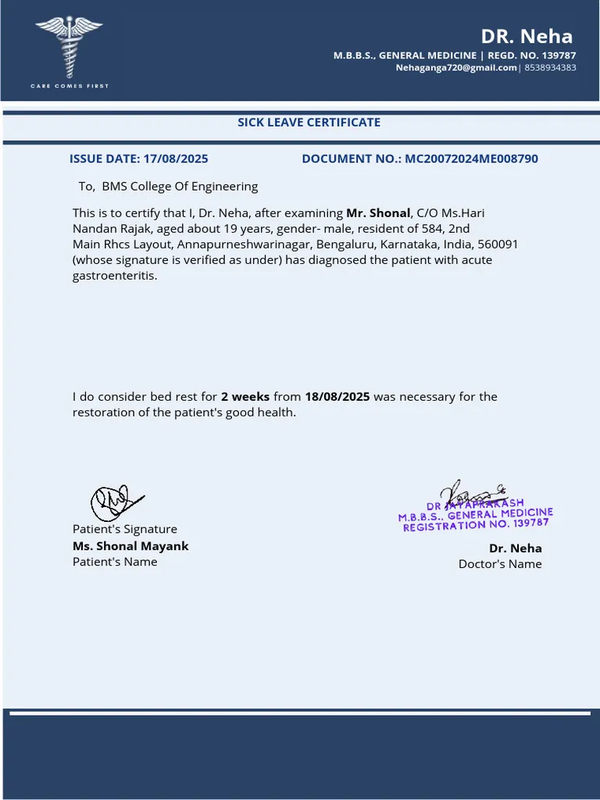

In [17]:
# Load and display the inspection image.
inspect_path = image_paths[INSPECT_INDEX]
inspect_image = load_image(inspect_path)

print(f"[{INSPECT_INDEX}] {inspect_path.name}")
print(f"Size: {inspect_image.size}  Mode: {inspect_image.mode}")
print()

# Display scaled down for notebook viewing.
display_width = 600
ratio = display_width / inspect_image.width
display_size = (display_width, int(inspect_image.height * ratio))
inspect_image.resize(display_size, Image.LANCZOS)

### Extract Fields from Inspection Image

Runs `extract_fields_donut()` on the loaded image and prints each field.

**Interpreting confidence:**
- **1.0** — Model returned a non-empty answer
- **0.0** — Model returned empty string (field not found in document)

> **Note:** Donut does not produce numeric confidence scores. A `1.0` means an answer
> was generated — it does not indicate certainty. Always visually verify results.

In [18]:
print(f"Extracting fields from: {inspect_path.name}")
print("=" * 60)

inspect_fields = extract_fields_donut(inspect_image)

print("\n=== Extracted Fields ===")
for field_name in _FIELD_QUESTIONS.keys():
    value = inspect_fields.get(field_name)
    confidence = inspect_fields.get(f"{field_name}_confidence", 0.0)

    indicator = "\u2713" if confidence == 1.0 else "\u2717"
    print(f"{indicator} {field_name:20s}: {value or '(not found)':40s}")

Extracting fields from: sicknote_1.png
Loading Donut model (naver-clova-ix/donut-base-finetuned-docvqa) — first call only, ~60–90 sec ...


Loading weights: 100%|██████████| 484/484 [00:00<00:00, 50771.39it/s]


Model moved to GPU (Apple MPS).
Donut model ready.

=== Extracted Fields ===
✓ patient_name        : ms. shonal mayank                       
✓ doctor_name         : dr. neha                                
✓ clinic_name         : patient's signature                     
✓ certificate_id      : m.b.b.s., general medicine              
✓ issue_date          : 17/08/2025                              


## Step 5 — Batch Processing

Runs the full pipeline on **every image in `IMAGE_FOLDER`** and collects the
results into a list of dicts (which the next cell turns into a DataFrame).

For each file:
1. Load image — `pdf_page_to_image()` for `.pdf`, otherwise `Image.open()`.
2. `extract_fields_donut()` → structured dictionary.
3. Append a merged row: `{file, subfolder, **fields}`.

The `except Exception` around each iteration is intentional — the batch loop
must keep going even if a single image fails, and the failure row records the
error string so you can spot it in the DataFrame.

In [19]:
results = []

for i, path in enumerate(image_paths):
    print(f"[{i+1}/{len(image_paths)}] Processing {path.name} ...", end=" ", flush=True)
    try:
        img = load_image(path)
        fields = extract_fields_donut(img)

        results.append({
            "file": path.name,
            "subfolder": path.parent.name,
            **fields,
        })

        patient = fields.get("patient_name") or "\u2014"
        date = fields.get("issue_date") or "\u2014"
        print(f"OK  (patient: {patient}, date: {date})")

    except Exception as exc:  # noqa: BLE001
        print(f"FAILED \u2014 {exc}")
        results.append({"file": path.name, "subfolder": path.parent.name, "error": str(exc)})

print(f"\nDone. {len(results)} image(s) processed.")

[1/23] Processing Sick_Note_1.jpg ...   [Image — 563×729 px]
OK  (patient: lovette dobson, date: may 19, 2021)
[2/23] Processing Sick_note_2.jpg ...   [Image — 736×952 px]
OK  (patient: t'erka harley date of birth: 08/02/1999, date: january 29, 2022)
[3/23] Processing Sick_note_8.pdf ...   [Native PDF — 150 DPI]
OK  (patient: mr. stephen collier, date: august 21, 1925)
[4/23] Processing sick_note_10.jpg ...   [Image — 450×582 px]
OK  (patient: general warning, date: 06/01/2017)
[5/23] Processing sick_note_12.pdf ...   [Native PDF — 150 DPI]
OK  (patient: b/l. le, date: monday june 28th, 2021)
[6/23] Processing sick_note_13.jpg ...   [Image — 1275×1650 px]
OK  (patient: —, date: 11/13/2017)
[7/23] Processing sick_note_14.pdf ...   [Native PDF — 150 DPI]
OK  (patient: nelly darwin, date: september 17, 2012)
[8/23] Processing sick_note_15.jpg ...   [Image — 1240×1754 px]
OK  (patient: nelly darwin, date: september 17, 1925)
[9/23] Processing sick_note_17.pdf ...   [Scanned PDF — 200 DPI]


### Results as a Pandas DataFrame

Builds a `pandas.DataFrame` with a human-friendly column order:

- **Priority columns first** — `file`, `subfolder`, then the main extracted fields.
- **Confidence columns** — grouped after each field value.
- **Error column** — at the end (only present for failed rows).

In [20]:
import pandas as pd
import json

print("=== Raw Results (JSON) ===")
print(json.dumps(results, indent=2, default=str))

df = pd.DataFrame(results)

priority_cols = [
    "file", "subfolder",
    "patient_name", "patient_name_confidence",
    "doctor_name", "doctor_name_confidence",
    "clinic_name", "clinic_name_confidence",
    "certificate_id", "certificate_id_confidence",
    "issue_date", "issue_date_confidence",
]
ordered_cols = [c for c in priority_cols if c in df.columns] + \
               [c for c in df.columns if c not in priority_cols]

pd.set_option("display.max_colwidth", 40)
pd.set_option("display.max_columns", 20)

print("\n=== Results DataFrame ===")
df[ordered_cols]

=== Raw Results (JSON) ===
[
  {
    "file": "Sick_Note_1.jpg",
    "subfolder": "Test data",
    "patient_name": "lovette dobson",
    "patient_name_confidence": 1.0,
    "doctor_name": "lovette dobson",
    "doctor_name_confidence": 1.0,
    "clinic_name": "lankenu medical center",
    "clinic_name_confidence": 1.0,
    "certificate_id": "may 19, 2021",
    "certificate_id_confidence": 1.0,
    "issue_date": "may 19, 2021",
    "issue_date_confidence": 1.0
  },
  {
    "file": "Sick_note_2.jpg",
    "subfolder": "Test data",
    "patient_name": "t'erka harley date of birth: 08/02/1999",
    "patient_name_confidence": 1.0,
    "doctor_name": "dr. jennifer a. greene",
    "doctor_name_confidence": 1.0,
    "clinic_name": "lexington medical center",
    "clinic_name_confidence": 1.0,
    "certificate_id": "t'eriza harley date of birth: 08/02/1999",
    "certificate_id_confidence": 1.0,
    "issue_date": "january 29, 2022",
    "issue_date_confidence": 1.0
  },
  {
    "file": "Sick_note

,file,subfolder,patient_name,patient_name_confidence,doctor_name,doctor_name_confidence,clinic_name,clinic_name_confidence,certificate_id,certificate_id_confidence,issue_date,issue_date_confidence
0,Sick_Note_1.jpg,Test data,lovette dobson,1.0,lovette dobson,1.0,lankenu medical center,1.0,"may 19, 2021",1.0,"may 19, 2021",1.0
1,Sick_note_2.jpg,Test data,t'erka harley date of birth: 08/02/1999,1.0,dr. jennifer a. greene,1.0,lexington medical center,1.0,t'eriza harley date of birth: 08/02/...,1.0,"january 29, 2022",1.0
2,Sick_note_8.pdf,Test data,mr. stephen collier,1.0,dr. gabriela richardson,1.0,gastroenterology specialist,1.0,325) 880-4213,1.0,"august 21, 1925",1.0
3,sick_note_10.jpg,Test data,general warning,1.0,drink plenty of water,1.0,florida hospital,1.0,06/01/2017,1.0,06/01/2017,1.0
4,sick_note_12.pdf,Test data,b/l. le,1.0,dr. rafael iiyayev,1.0,"rafael iiyayev, md",1.0,347,1.0,"monday june 28th, 2021",1.0
5,sick_note_13.jpg,Test data,NaN,0.0,dr. waters,1.0,medical excuse note,1.0,11/13/2017,1.0,11/13/2017,1.0
6,sick_note_14.pdf,Test data,nelly darwin,1.0,dr. riley snipes,1.0,evaluation summary,1.0,dr. riley snipes,1.0,"september 17, 2012",1.0
7,sick_note_15.jpg,Test data,nelly darwin,1.0,dr. riley snipes,1.0,evaluation summary,1.0,rley snipes,1.0,"september 17, 1925",1.0
8,sick_note_17.pdf,Test data,american examination confirmed the d...,1.0,"dr. sarah mitchell, md",1.0,northside family medical clinic,1.0,"august 3, 2016",1.0,"august 3, 2026",1.0
9,sick_note_18.pdf,Test data,the patient is receiving care for a ...,1.0,"dr. jessica monroe, dds",1.0,dentist doctor note,1.0,25 september 2025,1.0,september 2025,1.0


## Step 6 — Summary Statistics

Quick overview of extraction success rates across all processed images.

Since Donut uses binary confidence (1.0 / 0.0), the extraction rate directly reflects
how often the model produced a non-empty answer for each field.

In [21]:
print("=== Extraction Summary ===")
print(f"Total images processed: {len(results)}")
print()

for field_name in _FIELD_QUESTIONS.keys():
    extracted = sum(1 for r in results if r.get(field_name) is not None)
    pct = (extracted / len(results)) * 100 if results else 0
    print(f"{field_name:20s}: {extracted:2d}/{len(results)} extracted ({pct:5.1f}%)")

errors = sum(1 for r in results if "error" in r)
if errors:
    print(f"\nErrors: {errors} image(s) failed to process")

print()
print("Note: Confidence is binary (1.0/0.0) — Donut does not return numeric confidence scores.")

=== Extraction Summary ===
Total images processed: 23

patient_name        : 22/23 extracted ( 95.7%)
doctor_name         : 23/23 extracted (100.0%)
clinic_name         : 23/23 extracted (100.0%)
certificate_id      : 23/23 extracted (100.0%)
issue_date          : 23/23 extracted (100.0%)

Note: Confidence is binary (1.0/0.0) — Donut does not return numeric confidence scores.


## Appendix — Custom Question Testing

Use this cell to test custom questions on the inspection image. Helpful for
debugging extraction or trying alternative phrasings.

In [22]:
# Test custom questions on the inspection image.
custom_questions = [
    "What is the patient's name?",
    "What is the diagnosis?",
    "What is the sick leave period?",
    "From when to when is the sick leave?",
    "Is the patient fit for work?",
]

print(f"Testing custom questions on: {inspect_path.name}")
print("=" * 60)

# Encode image once — reused for all questions below.
_proc, _mdl = _get_donut()
_dev = next(_mdl.parameters()).device
_pv = _proc(inspect_image, return_tensors="pt").pixel_values.to(_dev)
with torch.no_grad():
    _enc = _mdl.encoder(pixel_values=_pv)

for question in custom_questions:
    answer = _ask_donut(_enc, question, _proc, _mdl, _dev)
    print(f"\nQ: {question}")
    print(f"A: {answer or '(no answer)'}")

Testing custom questions on: sicknote_1.png

Q: What is the patient's name?
A: ms. shonal mayank

Q: What is the diagnosis?
A: patient with acute gastroenteritis

Q: What is the sick leave period?
A: 17/08/2025

Q: From when to when is the sick leave?
A: 17/08/2025

Q: Is the patient fit for work?
A: ms. shonal mayank
